In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
df = sns.load_dataset('iris')

In [5]:
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [6]:
from sklearn.preprocessing import LabelEncoder

In [7]:
le = LabelEncoder()
df['species'] = le.fit_transform(df['species'])

In [8]:
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [12]:
df = df[df['species'] != 0][['sepal_width','petal_length','species']]

In [14]:
df.head()

,sepal_width,petal_length,species
50,3.2,4.7,1
51,3.2,4.5,1
52,3.1,4.9,1
53,2.3,4.0,1
54,2.8,4.6,1


<Axes: xlabel='sepal_width', ylabel='petal_length'>

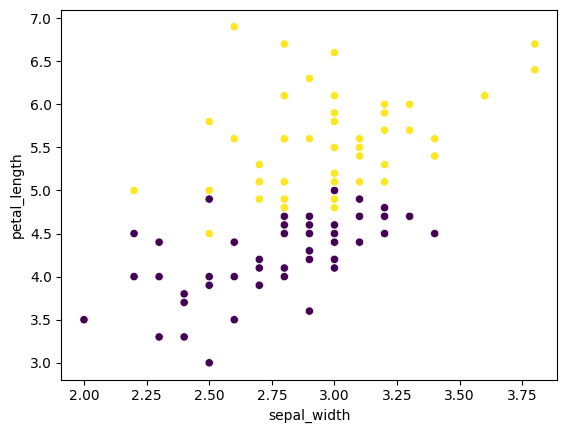

In [17]:
sns.scatterplot(y=df['petal_length'],x=df['sepal_width'],c=df['species'])

In [19]:
df_train = df.iloc[:60,:].sample(10)
df_train

,sepal_width,petal_length,species
80,2.4,3.8,1
91,3.0,4.6,1
68,2.2,4.5,1
99,2.8,4.1,1
79,2.6,3.5,1
76,2.8,4.8,1
96,2.9,4.2,1
51,3.2,4.5,1
75,3.0,4.4,1
97,2.9,4.3,1


In [20]:
df = df.sample(100)
df_train = df.iloc[:60,:].sample(10)
df_val = df.iloc[60:80,:].sample(5)
df_test = df.iloc[80:,:].sample(5)

In [21]:
df_train

,sepal_width,petal_length,species
133,2.8,5.1,2
85,3.4,4.5,1
60,2.0,3.5,1
50,3.2,4.7,1
76,2.8,4.8,1
82,2.7,3.9,1
130,2.8,6.1,2
125,3.2,6.0,2
114,2.8,5.1,2
139,3.1,5.4,2


In [22]:
df_val

,sepal_width,petal_length,species
64,2.9,3.6,1
115,3.2,5.3,2
121,2.8,4.9,2
63,2.9,4.7,1
148,3.4,5.4,2


In [23]:
df_test

,sepal_width,petal_length,species
68,2.2,4.5,1
65,3.1,4.4,1
95,3.0,4.2,1
141,3.1,5.1,2
120,3.2,5.7,2


In [24]:
X_test = df_val.iloc[:,0:2].values
y_test = df_val.iloc[:,-1].values

In [25]:
X_test

array([[2.9, 3.6],
       [3.2, 5.3],
       [2.8, 4.9],
       [2.9, 4.7],
       [3.4, 5.4]])

In [26]:
y_test

array([1, 2, 2, 1, 2])

# Case 1 - Bagging

In [29]:
# data for tree 1
df_bag = df_train.sample(8,replace=True)
X = df_bag.iloc[:,0:2]
y = df_bag.iloc[:,-1]

df_bag

,sepal_width,petal_length,species
82,2.7,3.9,1
114,2.8,5.1,2
85,3.4,4.5,1
60,2.0,3.5,1
76,2.8,4.8,1
60,2.0,3.5,1
82,2.7,3.9,1
50,3.2,4.7,1


In [30]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from mlxtend.plotting import plot_decision_regions
from sklearn.metrics import accuracy_score

In [31]:
def evaluate(clf,X,y):
    clf.fit(X,y)
    plot_tree(clf)
    plt.show()
    plot_decision_regions(X.values, y.values, clf=clf, legend=2)
    y_pred = clf.predict(X_test)
    print(accuracy_score(y_test,y_pred))

In [33]:
dt_bag1 = DecisionTreeClassifier()

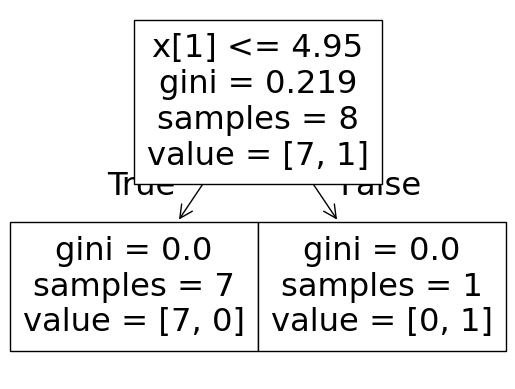

E:\ai-ml\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


0.8


E:\ai-ml\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


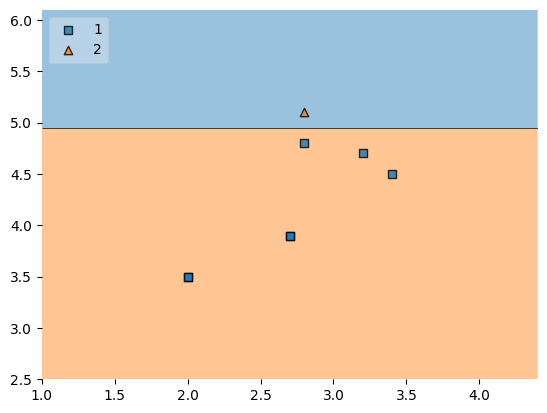

In [35]:
evaluate(dt_bag1,X,y)

In [36]:
# Data for Tree 1
df_bag = df_train.sample(8,replace=True)

# Fetch X and y
X = df_bag.iloc[:,0:2]
y = df_bag.iloc[:,-1]

# print df_bag
df_bag

,sepal_width,petal_length,species
139,3.1,5.4,2
130,2.8,6.1,2
50,3.2,4.7,1
82,2.7,3.9,1
125,3.2,6.0,2
139,3.1,5.4,2
114,2.8,5.1,2
85,3.4,4.5,1


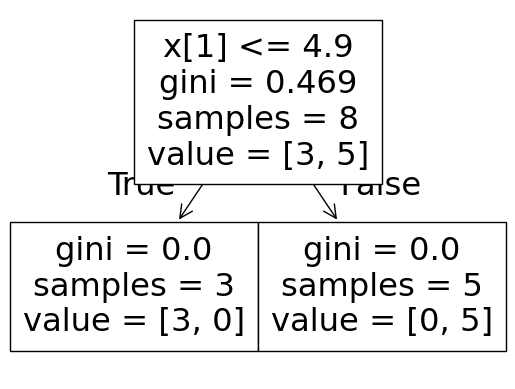

E:\ai-ml\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
E:\ai-ml\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


1.0


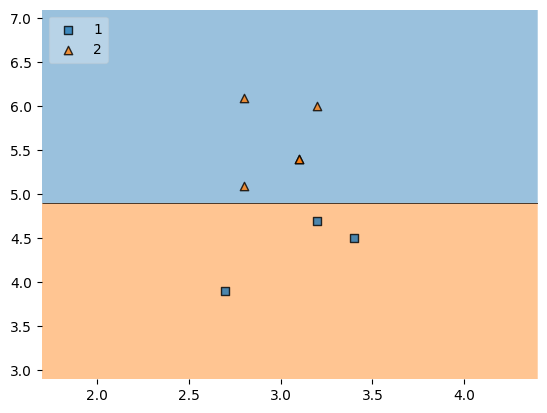

In [37]:
dt_bag2 = DecisionTreeClassifier()
evaluate(dt_bag2,X,y)

In [38]:

# Data for Tree 1
df_bag = df_train.sample(8,replace=True)

# Fetch X and y
X = df_bag.iloc[:,0:2]
y = df_bag.iloc[:,-1]

# print df_bag
df_bag

,sepal_width,petal_length,species
114,2.8,5.1,2
50,3.2,4.7,1
130,2.8,6.1,2
50,3.2,4.7,1
139,3.1,5.4,2
133,2.8,5.1,2
50,3.2,4.7,1
82,2.7,3.9,1


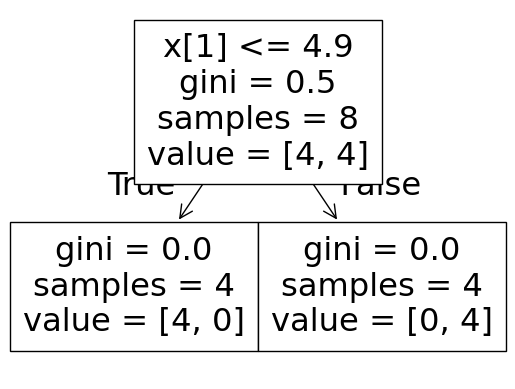

E:\ai-ml\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
E:\ai-ml\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


1.0


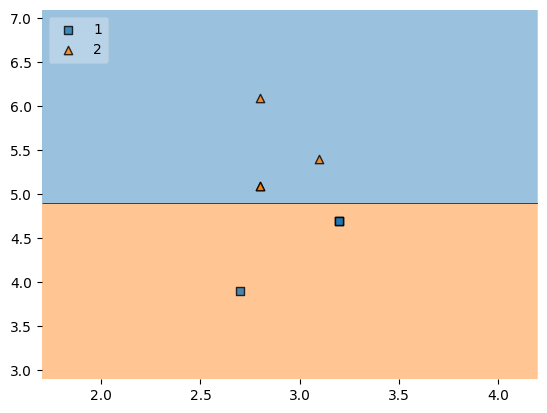

In [39]:

dt_bag3 = DecisionTreeClassifier()
evaluate(dt_bag3,X,y)

# Predict

In [40]:
df_test

,sepal_width,petal_length,species
68,2.2,4.5,1
65,3.1,4.4,1
95,3.0,4.2,1
141,3.1,5.1,2
120,3.2,5.7,2


In [43]:

print("Predictor 1",dt_bag1.predict(np.array([2.2,5.0]).reshape(1,2)))
print("Predictor 2",dt_bag2.predict(np.array([2.2,5.0]).reshape(1,2)))
print("Predictor 3",dt_bag3.predict(np.array([2.2,5.0]).reshape(1,2)))

Predictor 1 [2]
Predictor 2 [2]
Predictor 3 [2]


E:\ai-ml\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
E:\ai-ml\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
E:\ai-ml\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


# Pasting

In [44]:
df_train

,sepal_width,petal_length,species
133,2.8,5.1,2
85,3.4,4.5,1
60,2.0,3.5,1
50,3.2,4.7,1
76,2.8,4.8,1
82,2.7,3.9,1
130,2.8,6.1,2
125,3.2,6.0,2
114,2.8,5.1,2
139,3.1,5.4,2


# Random Subspaces

In [46]:
df1 = sns.load_dataset('iris')
df1.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [48]:
df.sample(10)

,sepal_width,petal_length,species
130,2.8,6.1,2
129,3.0,5.8,2
107,2.9,6.3,2
103,2.9,5.6,2
147,3.0,5.2,2
89,2.5,4.0,1
127,3.0,4.9,2
86,3.1,4.7,1
72,2.5,4.9,1
110,3.2,5.1,2


In [49]:
df1.sample(2,replace=True,axis=1) # col sampleing

,sepal_length,species
0,5.1,setosa
1,4.9,setosa
2,4.7,setosa
3,4.6,setosa
4,5.0,setosa
...,...,...
145,6.7,virginica
146,6.3,virginica
147,6.5,virginica
148,6.2,virginica


# Random Patches

In [51]:
df1

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


In [50]:
df1.sample(8,replace=True).sample(2,replace=True,axis=1) ## row and col sampleing

,sepal_length,petal_length
114,5.8,5.1
60,5.0,3.5
118,7.7,6.9
95,5.7,4.2
146,6.3,5.0
79,5.7,3.5
53,5.5,4.0
7,5.0,1.5
